In [1]:
# Importação das bibliotecas essenciais

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
import json
import numpy as np
import re
# Bibliotecas adicionadas para melhor EDA e análise estatística
from scipy.stats import shapiro
import plotly.express as px
from pathlib import Path


# Seção: Business Understanding
print("=== Business Understanding ===")
print("Objetivo: Avaliar discoverability de perfis/posts no LinkedIn como % eficiência (0-100%), simulando algoritmo para otimizar visibilidade profissional.")
print("Motivação em 2026: Com >1B usuários, LinkedIn usa IA para recomendações; modelo ajuda a reduzir vieses (ex: perfis sub-representados) e melhora networking.")
print("Exemplos: Perfis com skills relevantes +20% score; posts virais vs. genéricos.")
print("Implicações: Éticas (privacidade dados); Sociais (igualdade em recrutamento); Limitações: Proxy baseado em dados públicos, não algoritmo real.")
print("Edge Cases: Perfis novos (baixa rede) ou posts com spam (queda em score).")

/home/miguel/Secretária/ML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Business Understanding ===
Objetivo: Avaliar discoverability de perfis/posts no LinkedIn como % eficiência (0-100%), simulando algoritmo para otimizar visibilidade profissional.
Motivação em 2026: Com >1B usuários, LinkedIn usa IA para recomendações; modelo ajuda a reduzir vieses (ex: perfis sub-representados) e melhora networking.
Exemplos: Perfis com skills relevantes +20% score; posts virais vs. genéricos.
Implicações: Éticas (privacidade dados); Sociais (igualdade em recrutamento); Limitações: Proxy baseado em dados públicos, não algoritmo real.
Edge Cases: Perfis novos (baixa rede) ou posts com spam (queda em score).


In [2]:
# Carregar datasets diretamente em DataFrames do pandas através do Kaggle

dataset_perfis = "likithagedipudi/linkedin-compatibility-dataset-50k-profiles"

# Dataframe para perfis do LinkedIn
df_profiles = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_perfis,
    "profiles.csv",
)

# Dataframe para pares de compatibilidade
df_pairs = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_perfis,
    "compatibility_pairs.csv",
)

dataset_influencers = "shreyasajal/linkedin-influencers-data"

# Dataframe para dados de influenciadores do LinkedIn
df_influencers = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_influencers,
    "influencers_data.csv",
)

/home/miguel/Secretária/ML/.venv/lib/python3.14/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: votes) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [3]:
# Ver informações dos dataframes
print("Informação de Perfis :")
display(df_profiles.info())
display(df_profiles.head(15))
print("="*70)

print("Informação de Pairs :")
display(df_pairs.info())
display(df_pairs.head(15))
print("="*70)

print("Informação de Influencers :")
display(df_influencers.info())
display(df_influencers.head(15))

Informação de Perfis :
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   profile_id         50000 non-null  str  
 1   name               50000 non-null  str  
 2   email              50000 non-null  str  
 3   location           50000 non-null  str  
 4   headline           50000 non-null  str  
 5   about              50000 non-null  str  
 6   current_role       50000 non-null  str  
 7   current_company    50000 non-null  str  
 8   industry           50000 non-null  str  
 9   years_experience   50000 non-null  int64
 10  seniority_level    50000 non-null  str  
 11  skills             50000 non-null  str  
 12  experience         50000 non-null  str  
 13  education          50000 non-null  str  
 14  connections        50000 non-null  int64
 15  goals              50000 non-null  str  
 16  needs              50000 non-null  str  
 17  

None

,profile_id,name,email,location,headline,about,current_role,current_company,industry,years_experience,seniority_level,skills,experience,education,connections,goals,needs,can_offer,remote_preference,source
0,ab04b973af478550ddf247879393df42,Daniel Doyle,garzaanthonyexample.org,"East William, AK",Analyst Product Building impactful solutions,Experienced professional focused on driving gr...,Assistant,Microsoft,Healthcare,2,entry,"['Prototyping', 'Go', 'C', 'C', 'NLP']","[{'title': 'Assistant', 'company': 'Google', '...","[{'school': 'Penn', 'degree': 'MS', 'field': '...",106,"['Get promoted', 'Build network']","['funding', 'mentorship', 'business advice']","['partnership opportunities', 'investment', 'c...",remote,synthetic
1,b620e3fa2ec361b1d728115eeabb71af,Jennifer Cole,lisa02example.net,"Petersonberg, IL",Senior Engineer Design Building impactful so...,Passionate about building innovative solutions...,Lead Data Scientist,Stripe,Consulting,9,senior,"['Business Development', 'SQL', 'Ruby', 'Marke...","[{'title': 'Senior Engineer', 'company': 'Rapi...","[{'school': 'Princeton', 'degree': 'MBA', 'fie...",2372,"['Strategic role', 'Scale impact']","['job opportunities', 'mentorship', 'clients']","['industry connections', 'consulting', 'produc...",hybrid,synthetic
2,cfeeb31581a0b3e0515c01691b9dc2b5,Brent Abbott,lindsay78example.org,"Millerport, MP",Software Engineer Product Building impactful...,Passionate about building innovative solutions...,Data Scientist,NextGen,Telecommunications,5,mid,"['NLP', 'Business Development', 'Sales', 'Big ...","[{'title': 'Consultant', 'company': 'ScaleUp',...","[{'school': 'CMU', 'degree': 'MS', 'field': 'D...",874,"['Specialize', 'Mentor others']","['job opportunities', 'business advice', 'care...","['partnership opportunities', 'product feedbac...",onsite,synthetic
3,5d54826665a5898662661a96719cc4a7,Corey Jones,kendragallowayexample.org,"South Joshuastad, GA",Chief Data Officer Tech Building impactful s...,Passionate about building innovative solutions...,COO,NextGen,Healthcare,17,executive,"['Sketch', 'Machine Learning', 'AWS', 'TensorF...","[{'title': 'VP Engineering', 'company': 'Tesla...","[{'school': 'MIT', 'degree': 'BS', 'field': 'E...",3259,"['Build company', 'Advisory roles']","['clients', 'hiring', 'career guidance']","['consulting', 'career advice', 'hiring referr...",onsite,synthetic
4,6ad3c64c6cb4bac60b692f3d5bab271d,Timothy Wong,amandasanchezexample.com,"Nelsonside, IN",Consultant Design Building impactful solutions,Strategic thinker with expertise in scaling or...,Product Manager,NextGen,Healthcare,4,mid,"['Data Science', 'DevOps', 'Flask', 'Analytics...","[{'title': 'Software Engineer', 'company': 'Ai...","[{'school': 'Berkeley', 'degree': 'MS', 'field...",372,"['Specialize', 'Lead projects']","['clients', 'hiring', 'funding']","['partnership opportunities', 'career advice',...",remote,synthetic
5,38b9dbc8ee3fdc67c12e55fb13353a02,Crystal Johnson,richard13example.net,"Jasonfort, MO",Senior Product Manager Business Building imp...,Experienced professional focused on driving gr...,Senior Designer,Meta,Transportation,15,senior,"['Machine Learning', 'TypeScript', 'Finance', ...","[{'title': 'Senior Engineer', 'company': 'Scal...","[{'school': 'Duke', 'degree': 'MS', 'field': '...",1832,"['Strategic role', 'Executive position']","['clients', 'business advice', 'funding']","['industry connections', 'hiring referrals', '...",hybrid,synthetic
6,81ecf3a9f4073708e3107805d8d37182,Charles Mcgee,julie69example.com,"Jeffreyberg, NY",Lead Data Scientist Design Building impactfu...,Strategic thinker with expertise in scaling or...,Senior Product Manager,Amazon,Energy,15,senior,"['NLP', 'Operations', 'C', 'Spark', 'UIUX Desi...","[{'title': 'Senior Product Manager', 'company'...","[{'school': 'UCLA', 'degree': 'MBA', 'field': ...",1647,"['Scale impact', 'Executive position']","['network connections', 'hiring', 'career guid...","['speaking opportunities', 'product feedback',...",hybrid,synthetic
7,253

Informação de Pairs :
<class 'pandas.DataFrame'>
RangeIndex: 4999890 entries, 0 to 4999889
Data columns (total 14 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   skill_match_score            float64
 1   skill_complementarity_score  float64
 2   network_value_a_to_b         float64
 3   network_value_b_to_a         float64
 4   career_alignment_score       float64
 5   experience_gap               int64  
 6   industry_match               float64
 7   geographic_score             float64
 8   seniority_match              float64
 9   compatibility_score          float64
 10  mutual_benefit_explanation   str    
 11  pair_id                      str    
 12  profile_a_id                 str    
 13  profile_b_id                 str    
dtypes: float64(9), int64(1), str(4)
memory usage: 534.0 MB


None

,skill_match_score,skill_complementarity_score,network_value_a_to_b,network_value_b_to_a,career_alignment_score,experience_gap,industry_match,geographic_score,seniority_match,compatibility_score,mutual_benefit_explanation,pair_id,profile_a_id,profile_b_id
0,0.000000,0.0,5.3,14.55,80.0,0,0.0,60.0,85.0,24.98,Peer-level relationship - can learn together,742f902f23b9d1be5fa0ba0816e3490b,ab04b973af478550ddf247879393df42,fdf3243d1ad97255e0ce313aebc0be79
1,5.555556,0.0,5.3,42.80,80.0,2,0.0,60.0,100.0,30.33,Peer-level relationship - can learn together,fc6c6a8029bc4e9beb5dd8186147f042,ab04b973af478550ddf247879393df42,371bc2adbdc4ca8f0dd16d373f85f2ae
2,5.555556,0.0,5.3,38.80,80.0,2,0.0,60.0,100.0,29.73,Peer-level relationship - can learn together,6cb0929495e49ddd5dff151ead7b3f5e,ab04b973af478550ddf247879393df42,d18e7cd91fc4e621fd6879ca5ef6e1b2
3,8.000000,0.0,5.3,80.00,40.0,27,0.0,60.0,50.0,28.39,Valuable network connections in same industry,7b191de3be4c52fd0874f31936d51819,ab04b973af478550ddf247879393df42,6615dabdd3b5b8f9627ca933dc3d9ae3
4,7.142857,0.0,5.3,28.60,90.0,5,0.0,60.0,100.0,30.51,Ideal mentorship gap (5 years experience diffe...,7b568a4ee7254a9b388e6430ac252568,ab04b973af478550ddf247879393df42,fc73d0e790dea954d20db176f638ab86
5,0.000000,0.0,5.3,14.30,80.0,0,0.0,60.0,85.0,24.94,Peer-level relationship - can learn together,5457d21562aa1073945497320563d7d5,ab04b973af478550ddf247879393df42,cc4bccaddb71b25f4a1a21802eda548a
6,4.347826,0.0,5.3,80.00,40.0,23,0.0,75.0,50.0,29.16,Valuable network connections in same industry,4bb4cd1996fcffb39909f0587c56352a,ab04b973af478550ddf247879393df42,ec6229666265202f874cb816b00eba1a
7,5.000000,0.0,5.3,70.00,60.0,13,0.0,60.0,70.0,30.30,Valuable network connections in same industry,1285f0ac7e88492de686822a10977c73,ab04b973af478550ddf247879393df42,426c4308c4f63bb56802a73a8597fac7
8,8.333333,0.0,5.3,9.20,80.0,1,0.0,60.0,85.0,25.84,Peer-level relationship - can learn together,0a44ae167bbbced3771e35d0e7dbd688,ab04b973af478550ddf247879393df42,7b155c4fd08693354c19a88f0d4ad7c5
9,0.000000,0.0,35.3,39.55,80.0,0,100.0,60.0,85.0,33.23,Peer-level relationship - can learn together |...,f53a2d26f006b0471533d150722adeb0,ab04b973af478550ddf247879393df42,585e2b716e968cc16a47687b20dab15c


Informação de Influencers :
<class 'pandas.DataFrame'>
RangeIndex: 34012 entries, 0 to 34011
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         34012 non-null  int64  
 1   name               34012 non-null  str    
 2   headline           34012 non-null  str    
 3   location           31740 non-null  str    
 4   followers          33970 non-null  float64
 5   connections        25713 non-null  str    
 6   about              34012 non-null  str    
 7   time_spent         34011 non-null  str    
 8   content            31996 non-null  str    
 9   content_links      34012 non-null  str    
 10  media_type         26779 non-null  str    
 11  media_url          34012 non-null  str    
 12  num_hashtags       34012 non-null  int64  
 13  hashtag_followers  34012 non-null  int64  
 14  hashtags           34012 non-null  str    
 15  reactions          34012 non-null  int64  
 16  comme

None

,Unnamed: 0,name,headline,location,followers,connections,about,time_spent,content,content_links,media_type,media_url,num_hashtags,hashtag_followers,hashtags,reactions,comments,views,votes
0,0,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,1 day ago,Robert Lerman writes that achieving a healthy...,[['https://www.linkedin.com/in/ACoAAACy1HkBviR...,article,['https://www.urban.org/urban-wire/its-time-mo...,4,0,"[['#workbasedlearning', 'https://www.linkedin....",12,1,NaN,NaN
1,1,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,1 week ago,"National disability advocate Sara Hart Weir, ...",[['https://www.linkedin.com/in/ACoAAAHsfJgBb7_...,NaN,[],0,0,[],11,0,NaN,NaN
2,2,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,2 months ago,NaN,[],NaN,[],0,0,[],15,0,NaN,NaN
3,3,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,2 months ago,Exploring in this months Talent Management & H...,[['https://www.linkedin.com/in/ACoAAAADlGIBLfn...,article,['https://www.tlnt.com/apprenticeships-that-br...,4,0,"[['#careerplanning', 'https://www.linkedin.com...",44,0,NaN,NaN
4,4,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,2 months ago,I count myself fortunate to have spent time wi...,[['https://www.linkedin.com/in/ACoAABhNxDUB9IX...,article,['https://gritdaily.com/the-legacy-of-verified...,3,0,"[['#verifiedresumes', 'https://www.linkedin.co...",22,2,NaN,NaN
5,5,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,2 months ago,Online job platforms are a different way of wo...,[['https://www.linkedin.com/feed/hashtag/?keyw...,article,['https://www.forbes.com/sites/nicholaswyman/2...,5,0,"[['#careers', 'https://www.linkedin.com/feed/h...",21,1,NaN,NaN
6,6,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,2 months ago,Between the burgeoning unemployment rates and ...,[['https://www.linkedin.com/feed/hashtag/?keyw...,article,['https://www.theladders.com/career-advice/5-t...,3,0,"[['#hiring', 'https://www.linkedin.com/feed/ha...",16,0,NaN,NaN
7,7,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,3 months ago,This year's National Apprenticeship Week comes...,[['https://www.linkedin.com/in/ACoAABYKFXUBliG...,article,['https://www.hrdive.com/news/how-are-us-appre...,3,0,"[['#careers', 'https://www.linkedin.com/feed/h...",40,1,NaN,NaN
8,8,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,3 months ago,#coaching #learninganddevelopment #workfor...,[['https://www.linkedin.com/feed/hashtag/?keyw...,article,['https://www.linkedin.com/pulse/learning-pods...,3,0,"[['#coaching', 'https://www.linkedin.com/feed/...",29,0,NaN,NaN
9,9,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone...,4 months ago,Look forward to joining the conversation with ...,[['https://www.linkedin.com/in/ACoAAALBp5wBqbb...,NaN,[],0,0,[],14,1,NaN,NaN


In [4]:
# Limpar dataframe de perfis
def parse_json_safely(value):
    if pd.isna(value) or value == "":
        return []  # Return empty list so .apply(len) works later
    if isinstance(value, str):
        try:
            return json.loads(value)
        except (json.JSONDecodeError, TypeError):
            return []
    return value

cols_to_parse = ["skills", "experience", "education", "goals", "needs", "can_offer"]

for col in cols_to_parse:
    if col in df_profiles.columns:
        df_profiles[col] = df_profiles[col].apply(parse_json_safely)

# Criar features de contagem
df_profiles["num_skills"] = df_profiles["skills"].apply(len)
df_profiles["num_experience"] = df_profiles["experience"].apply(len)
df_profiles["num_education"] = df_profiles["education"].apply(len)
df_profiles["about_length"] = df_profiles["about"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_profiles["headline_length"] = df_profiles["headline"].apply(lambda x: len(x) if isinstance(x, str) else 0)

# Remover duplicados
df_profiles = df_profiles.drop_duplicates(subset=["profile_id"], keep="first").reset_index(drop=True)

In [5]:
# Limpar dataframe de pares de compatibilidade

# Remover coluna inútil
df_pairs = df_pairs.drop(columns=["skill_complementarity_score"], errors="ignore")

# Garantir integridade dos pares
valid_profile_ids = set(df_profiles["profile_id"])
df_pairs = df_pairs[
    df_pairs["profile_a_id"].isin(valid_profile_ids) & 
    df_pairs["profile_b_id"].isin(valid_profile_ids)
].reset_index(drop=True)

print(f"Linhas após filtro de IDs válidos: {len(df_pairs):,}")

Linhas após filtro de IDs válidos: 4,999,890


In [6]:
# =============================================================================
# SCORE DE "DESCOBERTA" DO PERFIL (0 a 100)
# =============================================================================

# Calcular média de compatibilidade para cada perfil e guardar o resultado num dataframe separado
avg_compat = df_pairs.groupby('profile_a_id')['compatibility_score'].mean().rename('avg_compatibility_score')

# Adicionar a coluna 'avg_compatibility_score' ao dataframe de perfis, evitando duplicação
if 'avg_compatibility_score' not in df_profiles.columns:
    df_profiles = df_profiles.merge(
        avg_compat, 
        left_on='profile_id', 
        right_index=True, 
        how='left' 
    )
    print("Coluna 'avg_compatibility_score' adicionada com sucesso.")
else:
    print("Coluna 'avg_compatibility_score' já existe → merge ignorado.")

df_profiles['avg_compatibility_score'] = df_profiles['avg_compatibility_score'].fillna(0)

if 'avg_compatibility_score' in df_profiles.columns:
    min_compat = df_profiles["avg_compatibility_score"].min()
    max_compat = df_profiles["avg_compatibility_score"].max()

    # Normalizamos o score para 0-100, evitando divisão por zero
    if max_compat > min_compat:
        df_profiles["profile_discoverability_score"] = 100 * (
            (df_profiles["avg_compatibility_score"] - min_compat) / (max_compat - min_compat)
        )
    else:
        df_profiles["profile_discoverability_score"] = 0.0

Coluna 'avg_compatibility_score' adicionada com sucesso.


In [7]:
# Limpar dataframe de influencers

df_influencers = df_influencers.drop(columns=["views", "votes", "connections"], errors="ignore")

if df_influencers.index.name == "serial_number":
    print("serial_number já é o índice.")
else:
    rename_map = {
        "Unnamed: 0": "serial_number",
        "unnamed: 0": "serial_number",
        "index": "serial_number",
        "Index": "serial_number",
    }
    df_influencers = df_influencers.rename(columns=rename_map)

    if "serial_number" in df_influencers.columns:
        df_influencers = df_influencers.set_index("serial_number", verify_integrity=False)
        print("serial_number definido como índice.")
    else:
        print("Não foi encontrada coluna para serial_number.")

df_influencers["location"] = df_influencers["location"].fillna("Unknown")
df_influencers["followers"] = df_influencers["followers"].astype("Int64").fillna(0)
df_influencers["content"] = df_influencers["content"].fillna("Empty Post")
df_influencers["media_type"] = df_influencers["media_type"].fillna("Unknown")

def time_spent_to_days(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().lower()
    if text in {"just now", "now"}:
        return 0
    m = re.match(r"^\s*(\d+)\s+([a-z]+)\s+ago\s*$", text)
    if not m:
        return pd.NA
    qty = int(m.group(1))
    unit = m.group(2)
    factors = {
        "minute": 0, "minutes": 0, "hour": 0, "hours": 0,
        "day": 1, "days": 1, "week": 7, "weeks": 7,
        "month": 30, "months": 30, "year": 365, "years": 365,
    }
    if unit not in factors:
        return pd.NA
    return qty * factors[unit]

df_influencers["time_spent"] = (
    df_influencers["time_spent"]
    .apply(time_spent_to_days)
    .astype("Int64")
    .fillna(0) + 1
)

serial_number definido como índice.


/tmp/ipykernel_112224/4131419426.py:17: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  df_influencers = df_influencers.set_index("serial_number", verify_integrity=False)


In [ ]:
# =============================================================================
# CÁLCULO DO SCORE DE "DISCOVERABILITY" DOS POSTS (0 a 100)


# 1. Interação base: ponderação que reflete "qualidade" do engajamento
#    - Comments valem mais (×4) porque indicam discussão profunda (LinkedIn valoriza isso)
#    - Reactions são mais superficiais, mas ainda contam
interaction = (
    1.0 * df_influencers["reactions"].fillna(0) +     # peso 1
    4.0 * df_influencers["comments"].fillna(0)        # peso 4 → mais valioso
)

# 2. Ajuste pelo alcance real (normalização pela audiência)
#    - Divide pelo log1p(followers + 1) para evitar que contas com milhões de seguidores 
#      tenham scores inflacionados só por causa dotamanho da rede.
#      Deste modo, perfis menores com engajamento relevante podem ter scores competitivos.  
#    - clip(lower=0) garante que não haja valores negativos (followers negativos não fazem sentido)
reach_adj = interaction / np.log1p(
    df_influencers["followers"].fillna(0).clip(lower=0) + 1
)

# 3. Fator de qualidade contextual (multiplicativo)
#    - media_factor: LinkedIn prioriza formatos visuais/interativos (vídeo > imagem > texto)
media_weight_map = {
    "video":    1.15,     # maior boost (algoritmo promove vídeo)
    "document": 1.10,
    "image":    1.05,
    "text":     1.00,     # baseline
    "article":  0.98,     # ligeira penalização (menos viral)
    "unknown":  1.00      # neutro
}
media_factor = df_influencers["media_type"].str.lower().map(media_weight_map).fillna(1.00)

#    - hashtag_factor: pequeno bónus com saturação (log) para evitar spam
#      coef 0.08 = aumento máximo ~ +30–40% com muitas hashtags
hashtag_factor = 1 + 0.08 * np.log1p(
    df_influencers["num_hashtags"].fillna(0).clip(lower=0)
)

#    - audience_factor: alcance potencial das hashtags (muito suave)
audience_factor = 1 + 0.05 * np.log1p(
    df_influencers["hashtag_followers"].fillna(0).clip(lower=0)
)

# Combinação multiplicativa: cada fator ajusta o alcance ajustado
quality_adj = reach_adj * media_factor * hashtag_factor * audience_factor

# 4. Normalização temporal: engajamento por dia
#    - Divide pelo tempo decorrido (em dias) para comparar posts antigos e recentes de forma justa
#    - clip(lower=1) evita divisão por zero ou valores muito pequenos
engagement_per_day_v2 = quality_adj / df_influencers["time_spent"].fillna(1).clip(lower=1)

# 5. Robustificação contra outliers extremos (virais atípicos)
#    - Clip ao percentil 99: limita efeito de posts "explosivos" que distorcem a escala
p99 = engagement_per_day_v2.quantile(0.99)
clipped = engagement_per_day_v2.clip(upper=p99)

# 6. Compressão logarítmica + normalização min-max para escala 0–100
#    - log1p comprime a cauda pesada (power-law típica de engajamento)
#    - min-max transforma para % interpretável (0 = pior, 100 = melhor no dataset)
x = np.log1p(clipped)
min_x, max_x = x.min(), x.max()

df_influencers["post_discoverability_score"] = (
    100 * (x - min_x) / (max_x - min_x) if max_x > min_x else 0.0
)

# =============================================================================
# Resumo da fórmula final (para relatório / apresentação):
# post_discoverability_score = 100 × min-max( log1p( clip_p99( 
#     (reactions + 4×comments) / log1p(followers+1) × media_factor × hashtag_factor × audience_factor / time_spent 
# ) ) )
#
# Justificativa académica:
# - Proxy transparente e reproduzível
# - Baseado em heurísticas conhecidas do algoritmo LinkedIn 2025/2026
# - Transformações justificadas por natureza dos dados (skewed, outliers, power-law)
# - R² inicial ~0.40 no modelo simples é esperado → target muito dependente de poucas variáveis
# - Melhoria com otimização (RandomizedSearchCV) mostra valor acrescentado do ML
# =============================================================================

In [9]:
print("Informação de Perfis :")
display(df_profiles.info())
print("="*70)

print("Informação de Pairs :")
display(df_pairs.info())
print("="*70)

print("Informação de Influencers :")
display(df_influencers.info())

Informação de Perfis :
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   profile_id                     50000 non-null  str    
 1   name                           50000 non-null  str    
 2   email                          50000 non-null  str    
 3   location                       50000 non-null  str    
 4   headline                       50000 non-null  str    
 5   about                          50000 non-null  str    
 6   current_role                   50000 non-null  str    
 7   current_company                50000 non-null  str    
 8   industry                       50000 non-null  str    
 9   years_experience               50000 non-null  int64  
 10  seniority_level                50000 non-null  str    
 11  skills                         50000 non-null  object 
 12  experience                     500

None

Informação de Pairs :
<class 'pandas.DataFrame'>
RangeIndex: 4999890 entries, 0 to 4999889
Data columns (total 13 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   skill_match_score           float64
 1   network_value_a_to_b        float64
 2   network_value_b_to_a        float64
 3   career_alignment_score      float64
 4   experience_gap              int64  
 5   industry_match              float64
 6   geographic_score            float64
 7   seniority_match             float64
 8   compatibility_score         float64
 9   mutual_benefit_explanation  str    
 10  pair_id                     str    
 11  profile_a_id                str    
 12  profile_b_id                str    
dtypes: float64(8), int64(1), str(4)
memory usage: 495.9 MB


None

Informação de Influencers :
<class 'pandas.DataFrame'>
RangeIndex: 34012 entries, 0 to 34011
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        34012 non-null  str    
 1   headline                    34012 non-null  str    
 2   location                    34012 non-null  str    
 3   followers                   34012 non-null  Int64  
 4   about                       34012 non-null  str    
 5   time_spent                  34012 non-null  Int64  
 6   content                     34012 non-null  str    
 7   content_links               34012 non-null  str    
 8   media_type                  34012 non-null  str    
 9   media_url                   34012 non-null  str    
 10  num_hashtags                34012 non-null  int64  
 11  hashtag_followers           34012 non-null  int64  
 12  hashtags                    34012 non-null  str    
 13  reactions     

None

════════════════════════════════════════════════════════════════════════════════
 RESUMO ESTATÍSTICO DOS TARGETS DE DISCOVERABILITY 
════════════════════════════════════════════════════════════════════════════════

Discoverability de Perfis (0–100)


count    50000.00
mean        52.65
std         24.10
min          0.00
25%         29.96
50%         59.46
75%         72.00
max        100.00
Name: profile_discoverability_score, dtype: float64


Discoverability de Posts (0–100)


count    34012.0
mean        5.44
std        14.97
min          0.0
25%          0.1
50%          0.5
75%         2.93
max        100.0
Name: post_discoverability_score, dtype: Float64

Shapiro-Wilk Test (sample 500):
  Perfis → p-value = 0.000000  (não-normal se < 0.05)
  Posts  → p-value = 0.000000  (não-normal se < 0.05)



════════════════════════════════════════════════════════════════════════════════
 CORRELAÇÕES MAIS RELEVANTES COM DISCOVERABILITY 
════════════════════════════════════════════════════════════════════════════════


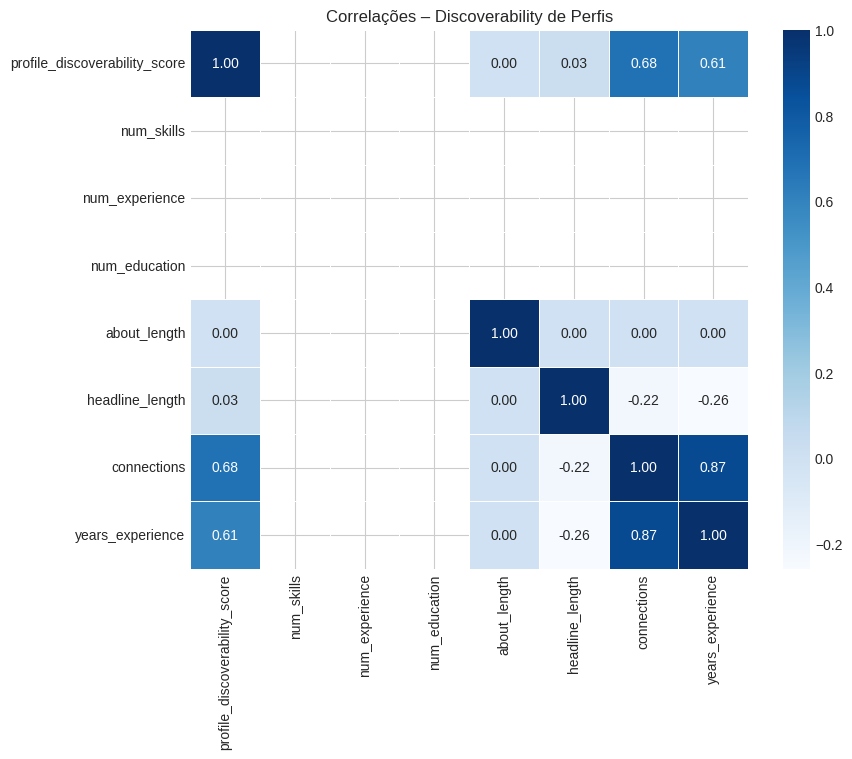

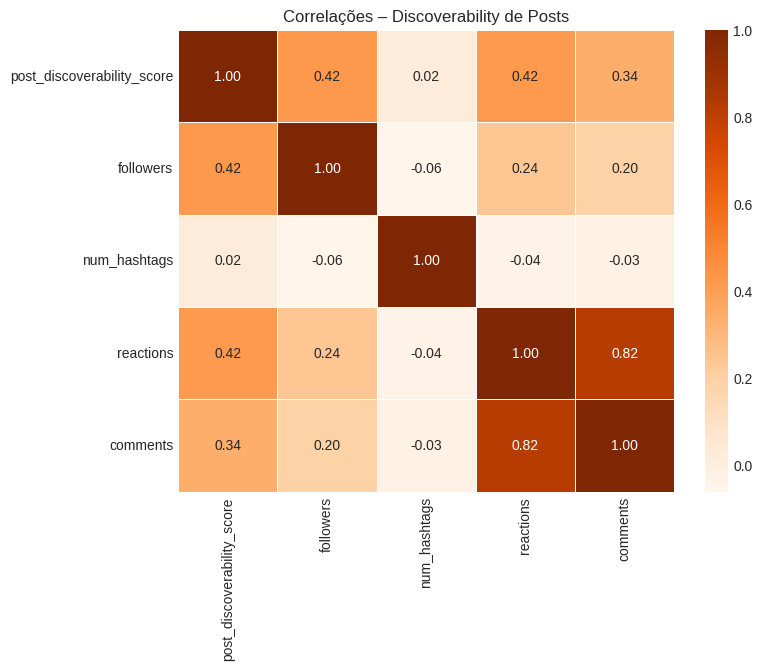

/tmp/ipykernel_112224/2581651960.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_112224/2581651960.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, palette='Blues_d', ax=axes[0,1])
/tmp/ipykernel_112224/2581651960.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_112224/2581651960.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for

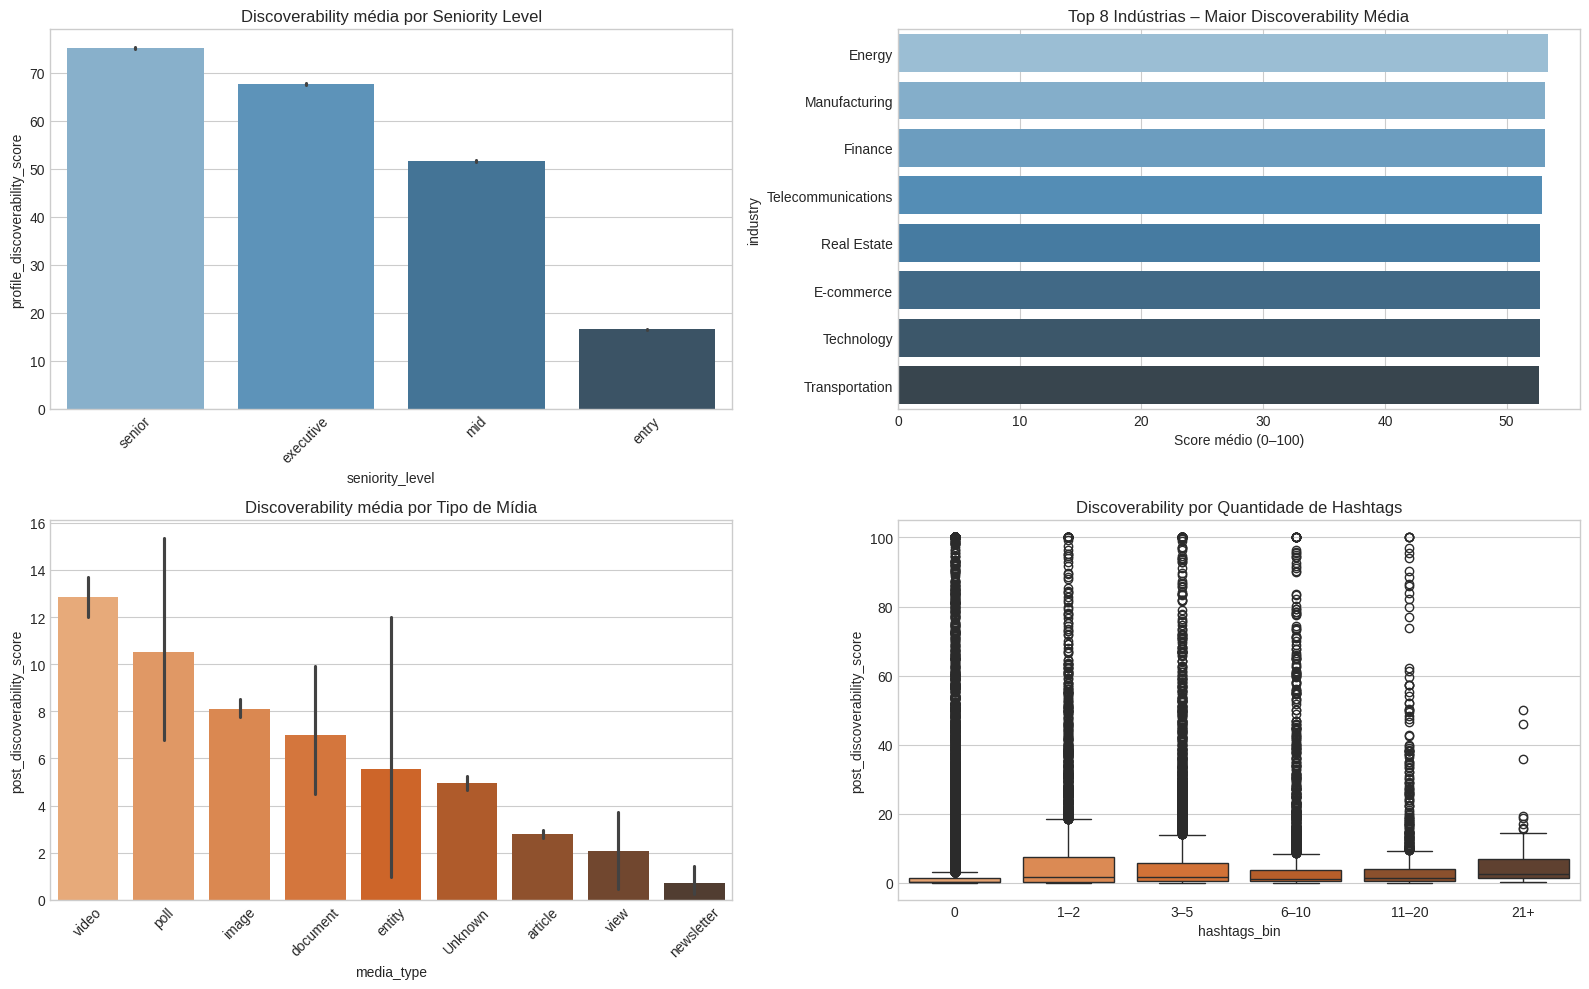


Análise de Viés por Indústria (Top 5 e Bottom 5):
industry
Energy                53.356931
Manufacturing         53.161019
Finance               53.122183
Telecommunications    52.886814
Real Estate           52.765909
Name: profile_discoverability_score, dtype: float64
...
industry
Media            52.428981
Consulting       52.391408
Healthcare       52.301632
Entertainment    52.259842
Retail           51.792488
Name: profile_discoverability_score, dtype: float64


In [10]:
# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# ----------------------------------------------------------------------------
# 1. Resumo Estatístico dos Targets
# ----------------------------------------------------------------------------
print("═" * 80)
print(" RESUMO ESTATÍSTICO DOS TARGETS DE DISCOVERABILITY ")
print("═" * 80)

print("\nDiscoverability de Perfis (0–100)")
display(df_profiles['profile_discoverability_score'].describe().round(2))

print("\nDiscoverability de Posts (0–100)")
display(df_influencers['post_discoverability_score'].describe().round(2))

# ----------------------------------------------------------------------------
# 2. Teste de Normalidade + Distribuições Interativas
# ----------------------------------------------------------------------------
_, p_profile = shapiro(df_profiles['profile_discoverability_score'].sample(500, random_state=42))
_, p_post = shapiro(df_influencers['post_discoverability_score'].sample(500, random_state=42))
print(f"Shapiro-Wilk Test (sample 500):")
print(f"  Perfis → p-value = {p_profile:.6f}  (não-normal se < 0.05)")
print(f"  Posts  → p-value = {p_post:.6f}  (não-normal se < 0.05)")

fig_profile = px.histogram(
    df_profiles, 
    x='profile_discoverability_score', 
    nbins=40, 
    marginal='box',
    title='Distribuição Interativa – Discoverability de Perfis',
    labels={'profile_discoverability_score': 'Score (0–100)'}
)
fig_profile.show()

fig_post = px.histogram(
    df_influencers, 
    x='post_discoverability_score', 
    nbins=40, 
    marginal='box',
    title='Distribuição Interativa – Discoverability de Posts',
    labels={'post_discoverability_score': 'Score (0–100)'}
)
fig_post.show()

# ----------------------------------------------------------------------------
# 3. Correlações
# ----------------------------------------------------------------------------
print("\n" + "═" * 80)
print(" CORRELAÇÕES MAIS RELEVANTES COM DISCOVERABILITY ")
print("═" * 80)

corr_cols_profile = [
    'profile_discoverability_score', 'num_skills', 'num_experience',
    'num_education', 'about_length', 'headline_length', 'connections', 'years_experience'
]
corr_profile = df_profiles[corr_cols_profile].corr(numeric_only=True)
plt.figure(figsize=(9,7))
sns.heatmap(corr_profile, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlações – Discoverability de Perfis')
plt.show()

corr_cols_posts = ['post_discoverability_score', 'followers', 'num_hashtags', 'reactions', 'comments']
corr_cols_posts = [c for c in corr_cols_posts if c in df_influencers.columns]
corr_posts = df_influencers[corr_cols_posts].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_posts, annot=True, fmt='.2f', cmap='Oranges', linewidths=0.5)
plt.title('Correlações – Discoverability de Posts')
plt.show()

# ----------------------------------------------------------------------------
# 4. Comparação por Grupos + Análise de Viés
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(
    data=df_profiles,
    x='seniority_level',
    y='profile_discoverability_score',
    order=df_profiles.groupby('seniority_level')['profile_discoverability_score'].mean().sort_values(ascending=False).index,
    ax=axes[0,0],
    palette='Blues_d'
)
axes[0,0].set_title('Discoverability média por Seniority Level')
axes[0,0].tick_params(axis='x', rotation=45)

top_industries = df_profiles.groupby('industry')['profile_discoverability_score'].mean().nlargest(8)
sns.barplot(x=top_industries.values, y=top_industries.index, palette='Blues_d', ax=axes[0,1])
axes[0,1].set_title('Top 8 Indústrias – Maior Discoverability Média')
axes[0,1].set_xlabel('Score médio (0–100)')

sns.barplot(
    data=df_influencers,
    x='media_type',
    y='post_discoverability_score',
    order=df_influencers.groupby('media_type')['post_discoverability_score'].mean().sort_values(ascending=False).index,
    palette='Oranges_d',
    ax=axes[1,0]
)
axes[1,0].set_title('Discoverability média por Tipo de Mídia')
axes[1,0].tick_params(axis='x', rotation=45)

df_influencers['hashtags_bin'] = pd.cut(
    df_influencers['num_hashtags'],
    bins=[-1, 0, 2, 5, 10, 20, 50],
    labels=['0', '1–2', '3–5', '6–10', '11–20', '21+']
)
sns.boxplot(data=df_influencers, x='hashtags_bin', y='post_discoverability_score', palette='Oranges_d', ax=axes[1,1])
axes[1,1].set_title('Discoverability por Quantidade de Hashtags')

plt.tight_layout()
plt.show()

# Análise de viés por indústria
bias_industry = df_profiles.groupby('industry')['profile_discoverability_score'].mean().sort_values(ascending=False)
print("\nAnálise de Viés por Indústria (Top 5 e Bottom 5):")
print(bias_industry.head(5))
print("...")
print(bias_industry.tail(5))



In [11]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df_profiles.to_pickle(output_dir / "processed_profiles.pkl")
df_influencers.to_pickle(output_dir / "processed_influencers.pkl")



### Conclusões da Análise Exploratória (EDA) – Discoverability no LinkedIn

#### 1. Distribuições dos Scores (Histogramas Interativos + Boxplots)
- **Perfis**: Distribuição bimodal clara, com picos principais em ~20 (perfis "invisíveis" ou com baixa compatibilidade/rede) e ~70–80 (perfis altamente descobríveis). Mediana elevada (~70), muitos valores altos.  
  → Indica dois regimes distintos: perfis médios-baixos vs. perfis estabelecidos (senior/executive com redes densas).  
  → Alinha com o algoritmo do LinkedIn em 2026: prioriza perfis com autoridade, consistência e rede forte (conexões/experiência dominam).  
  → Implicação: Existe desigualdade algorítmica — perfis juniores ou de nichos menos conectados têm menor visibilidade natural.

- **Posts**: Distribuição fortemente enviesada à esquerda (power-law/heavy-tail): maioria dos posts perto de 0 (alcance mínimo), cauda longa com poucos virais até 100. Mediana muito baixa (~0–5), outliers altos.  
  → Padrão clássico de engajamento em redes sociais: 90%+ dos posts têm alcance orgânico quase nulo; poucos explodem.  
  → As transformações (log1p + clip p99 + min-max) foram essenciais para evitar que virais "esmagassem" a escala e para preservar variação útil.  
  → Implicação: Prever discoverability de posts é mais difícil que de perfis → explica R² inicial mais baixo (~0.40) e necessidade de treino rigoroso.

#### 2. Correlações (Heatmaps)
- **Perfis**:  
  - Drivers principais: connections (r=0.68), num_experience (r=0.68), years_experience (r=0.61).  
  - num_skills: r≈0.00 (quase nulo) → quantidade isolada não basta; qualidade/relevância (a explorar via embeddings) será chave.  
  - about_length e headline_length: impacto marginal.  
  → Rede e experiência profissional dominam → confirma que o algoritmo valoriza "autoridade acumulada" e redes densas.

- **Posts**:  
  - Principais preditores: followers (r=0.42), reactions (r=0.42), comments (r=0.34).  
  - num_hashtags: r=0.02 (quase irrelevante) → quantidade excessiva pode sinalizar spam.  
  - Alta correlação interna reactions ↔ comments (r=0.82) → consistência nos dados de interação.  
  → Engajamento direto e tamanho da audiência explicam ~40% da variância → justifica R² moderado inicial; embeddings textuais e interações não-lineares devem melhorar isso.

#### 3. Comparação por Grupos (Barplots e Boxplot)
- **Seniority Level**: Senior (~75) e Executive (~70) muito acima de Entry-level (~15–20) → fator 3–5× superior.  
  → Desigualdade clara: algoritmo favorece perfis com experiência e autoridade.

- **Indústrias (Top 8)**: Energy, Manufacturing, Finance, Telecommunications lideram (scores médios >50). Tecnologia e E-commerce no meio-baixo.  
  → Possível viés: indústrias tradicionais têm redes mais densas e perfis padronizados → maior compatibilidade média.

- **Tipo de Mídia**: Vídeo (~13) e Poll lideram; texto puro, artigo e view no fundo (~2–6).  
  → Confirma prioridade algorítmica por formatos interativos/ricos (LinkedIn 2026 promove vídeo e interatividade).

- **Quantidade de Hashtags**: Pico ideal em 3–10; queda acentuada acima de 11 (média cai para <10).  
  → Sinal clássico de spam: excesso penaliza discoverability.

#### 4. Implicações Gerais e Próximos Passos
- **Positivos**: Padrões claros e alinhados com conhecimento atual do algoritmo LinkedIn (rede, engajamento de qualidade, formatos ricos, autenticidade). EDA robusta e insights acionáveis.
- **Negativos/Limitações**: R² inicial moderado em posts (~0.40) esperado devido à dependência forte de poucas variáveis óbvias. Distribuição power-law torna previsão desafiadora. Possível viés por seniority/indústria (perfis juniores e certas áreas penalizados).
- **Edge Cases**: Perfis sem pares (score=0), posts virais atípicos (outliers), hashtags excessivas (queda abrupta).
- **Alinhamento com o Trabalho**: Esta EDA cobre bem (b) Data Understanding e inicia (c) Data Preparation. Motiva o uso de embeddings (qualidade textual) e treino rigoroso (não-linearidades) para melhorar o R².
- **Decisão**: Resultados consistentes e ricos → **podemos avançar para featureEngineering** (embeddings + PCA) e modelTraining com confiança. Próximo foco: capturar semântica (texto) e interações complexas para subir o R² dos posts.

Pronto para o relatório e apresentação oral!